# Retail Sales & Customer Behavior Analysis

## Objective
This project analyzes online retail transactions to identify sales patterns, customer behavior, product demand, seasonality, and country-level revenue contribution.

## Business Goal
The aim is to turn raw transaction data into practical insights that can support inventory planning, customer retention, market prioritization, and revenue tracking.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

## Load the Dataset
The dataset contains invoice-level retail transactions for an online store. Each row represents a product line within an invoice, along with quantity, price, customer identifier, invoice timestamp, and country.

In [6]:
df = pd.read_csv("input_data/data.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## Dataset Overview
The raw dataset includes the following business fields:

- **InvoiceNo**: invoice identifier for each transaction
- **StockCode**: unique product code
- **Description**: product name or description
- **Quantity**: number of units in the line item
- **InvoiceDate**: date and time of purchase
- **UnitPrice**: price per unit
- **CustomerID**: customer identifier
- **Country**: customer country

A quick profile of the raw data helps surface issues such as missing customer IDs, duplicate rows, returns, cancelled invoices, and non-positive prices before moving into analysis.

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,"541,909.00","541,909.00","406,829.00"
mean,9.55,4.61,"15,287.69"
std,218.08,96.76,"1,713.60"
min,"-80,995.00","-11,062.06","12,346.00"
25%,1.00,1.25,"13,953.00"
50%,3.00,2.08,"15,152.00"
75%,10.00,4.13,"16,791.00"
max,"80,995.00","38,970.00","18,287.00"


## Initial Data Quality Assessment
Before cleaning, the notebook measures the size of the raw dataset and checks the main issues that can distort business metrics. These checks are useful because transactional retail data often includes cancellations, returns, incomplete customer records, and duplicate rows.

In [8]:
print(f"Raw dataset shape: {df.shape}")
print(f"Missing CustomerID rows: {df['CustomerID'].isna().sum()} ({df['CustomerID'].isna().mean() * 100:.2f}%)")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Cancelled invoices: {df['InvoiceNo'].astype(str).str.startswith('C').sum()}")
print(f"Negative quantity rows: {(df['Quantity'] < 0).sum()}")
print(f"Zero or negative UnitPrice rows: {(df['UnitPrice'] <= 0).sum()}")

Raw dataset shape: (541909, 8)
Missing CustomerID rows: 135080 (24.93%)
Duplicate rows: 5268
Cancelled invoices: 9288
Negative quantity rows: 10624
Zero or negative UnitPrice rows: 2517


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning
The cleaning steps below create an analysis-ready dataset focused on valid completed purchases. The rules are intentionally simple and business-friendly:

- remove rows with missing `CustomerID` for customer-level analysis
- remove exact duplicates
- remove cancelled invoices
- keep only positive quantities and positive prices
- standardize data types for dates and customer IDs

In [10]:
df = df.dropna(subset=['CustomerID']).drop_duplicates().copy()
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned dataset shape: {df.shape}")
print(f"Remaining null values: {df.isnull().sum().sum()}")
print(f"Remaining duplicates: {df.duplicated().sum()}")

Cleaned dataset shape: (392692, 8)
Remaining null values: 0
Remaining duplicates: 0


In [11]:
post_clean_checks = pd.Series({
    'rows_after_cleaning': len(df),
    'remaining_null_customerid': int(df['CustomerID'].isna().sum()),
    'remaining_duplicates': int(df.duplicated().sum()),
    'remaining_non_positive_quantity': int((df['Quantity'] <= 0).sum()),
    'remaining_non_positive_price': int((df['UnitPrice'] <= 0).sum()),
    'date_range_start': df['InvoiceDate'].min(),
    'date_range_end': df['InvoiceDate'].max()
})
post_clean_checks

rows_after_cleaning                             392692
remaining_null_customerid                            0
remaining_duplicates                                 0
remaining_non_positive_quantity                      0
remaining_non_positive_price                         0
date_range_start                   2010-12-01 08:26:00
date_range_end                     2011-12-09 12:50:00
dtype: object

The validation output confirms that the final analytical dataset no longer contains the key issues targeted in the cleaning step.

## Feature Engineering
To support sales analysis, new derived fields are added:

- **Revenue** = `Quantity x UnitPrice`
- **Month** = monthly period extracted from `InvoiceDate`

These features make it easier to calculate revenue, compare periods, and summarize performance across customers, products, and countries.

In [12]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


## KPI Snapshot
Before deep-diving into individual charts, the following metrics provide a quick business summary of the cleaned dataset. These are the kinds of numbers a stakeholder or recruiter can interpret immediately.

In [13]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Unique Customers',
        'Total Orders',
        'Unique Products',
        'Total Revenue',
        'Average Revenue per Customer',
        'Average Order Value',
        'Repeat Customer Rate (%)'
    ],
    'Value': [
        df['CustomerID'].nunique(),
        df['InvoiceNo'].nunique(),
        df['StockCode'].nunique(),
        round(df['Revenue'].sum(), 2),
        round(df.groupby('CustomerID')['Revenue'].sum().mean(), 2),
        round(df.groupby('InvoiceNo')['Revenue'].sum().mean(), 2),
        round(df.groupby('CustomerID')['InvoiceNo'].nunique().gt(1).mean() * 100, 2)
    ]
})

kpi_summary

,Metric,Value
0,Unique Customers,"4,338.00"
1,Total Orders,"18,532.00"
2,Unique Products,"3,665.00"
3,Total Revenue,"8,887,208.89"
4,Average Revenue per Customer,"2,048.69"
5,Average Order Value,479.56
6,Repeat Customer Rate (%),65.58


## Customer Concentration Analysis
This section tests how strongly revenue is concentrated across customers. Segmenting customers into revenue quintiles makes the portfolio insight measurable rather than anecdotal.

In [14]:
customer_segments = (
    df.groupby('CustomerID')
      .agg(total_revenue=('Revenue', 'sum'), order_count=('InvoiceNo', 'nunique'))
      .reset_index()
)

customer_segments['revenue_segment'] = pd.qcut(
    customer_segments['total_revenue'],
    q=5,
    labels=['Bottom 20%', 'Q2', 'Q3', 'Q4', 'Top 20%']
)

segment_summary = (
    customer_segments.groupby('revenue_segment', observed=False)
      .agg(customers=('CustomerID', 'count'), revenue=('total_revenue', 'sum'))
      .reset_index()
)
segment_summary['revenue_share_pct'] = (segment_summary['revenue'] / segment_summary['revenue'].sum() * 100).round(2)
segment_summary

,revenue_segment,customers,revenue,revenue_share_pct
0,Bottom 20%,868,"132,438.17",1.49
1,Q2,867,"310,003.31",3.49
2,Q3,868,"594,005.68",6.68
3,Q4,867,"1,213,460.91",13.65
4,Top 20%,868,"6,637,300.82",74.68


The result shows a strong Pareto-style pattern: the top 20% of customers contribute about 74.68% of total revenue. This is a much stronger and more defensible claim than a vague statement that a few customers are important.

In [15]:
repeat_buyers = customer_segments[customer_segments['order_count'] > 1].copy()
top20_threshold = customer_segments['total_revenue'].quantile(0.8)

top20_customer_count = customer_segments.loc[
    customer_segments['total_revenue'] >= top20_threshold, 'CustomerID'
].nunique()
repeat_orders_total = repeat_buyers['order_count'].sum()
top20_repeat_orders = repeat_buyers.loc[
    repeat_buyers['total_revenue'] >= top20_threshold, 'order_count'
].sum()

concentration_metrics = pd.DataFrame({
    'Metric': [
        'Top 20% customers (count)',
        'Repeat buyers (count)',
        'Share of repeat buyers in top 20% (%)',
        'Share of repeat orders from top 20% customers (%)'
    ],
    'Value': [
        top20_customer_count,
        repeat_buyers['CustomerID'].nunique(),
        round((repeat_buyers['total_revenue'] >= top20_threshold).mean() * 100, 2),
        round(top20_repeat_orders / repeat_orders_total * 100, 2)
    ]
})
concentration_metrics

,Metric,Value
0,Top 20% customers (count),868.00
1,Repeat buyers (count),"2,845.00"
2,Share of repeat buyers in top 20% (%),30.02
3,Share of repeat orders from top 20% customers (%),59.73


A key correction is made here: `30.02%` is the share of repeat buyers who fall into the top-20%-revenue segment, not the share of repeat purchases. The stronger portfolio insight is that top-20%-revenue customers account for about 59.73% of repeat orders.

## Total Revenue Generated
Revenue is the core business output of this dataset. Calculating total revenue after cleaning ensures that invalid records do not inflate the result.

In [16]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 8887208.89


## Top Selling Products
This section identifies the products with the highest quantity sold. These items are useful for inventory planning, demand forecasting, and merchandising decisions.

In [17]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

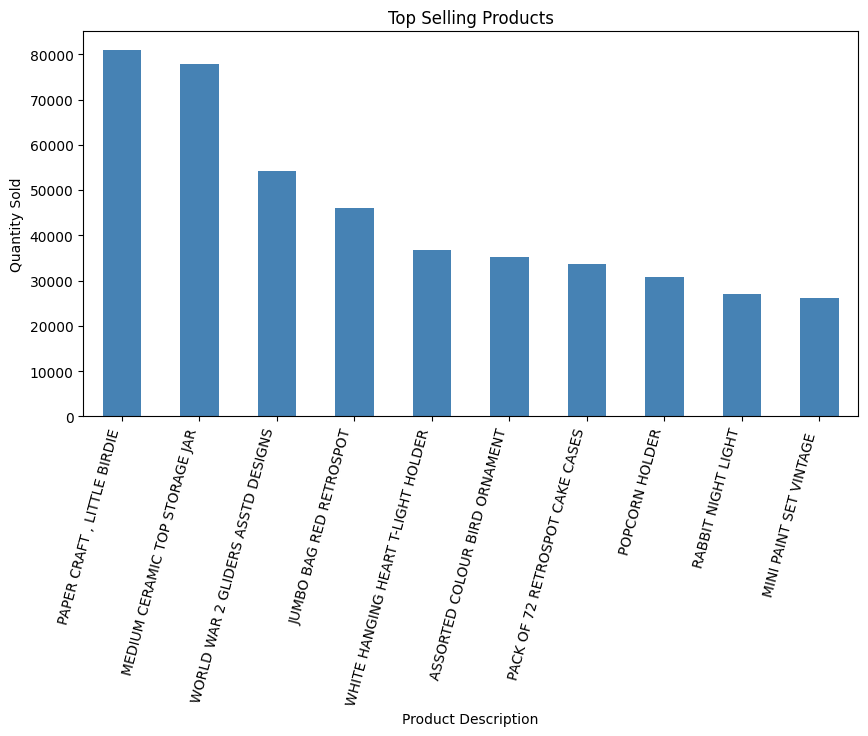

In [18]:
top_products.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title("Top Selling Products")
plt.ylabel("Quantity Sold")
plt.xlabel("Product Description")
plt.xticks(rotation=75, ha='right')
plt.show()

Products with consistently high volumes should be monitored for stock availability, supplier reliability, and promotion timing.

## Revenue Contribution by Country
Country-level revenue shows where the business is strongest geographically. A concentrated revenue mix can be a growth opportunity, but it can also indicate market dependence risk.

In [19]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_sales

Country
United Kingdom   7,285,024.64
Netherlands        285,446.34
EIRE               265,262.46
Germany            228,678.40
France             208,934.31
Australia          138,453.81
Spain               61,558.56
Switzerland         56,443.95
Belgium             41,196.34
Sweden              38,367.83
Name: Revenue, dtype: float64

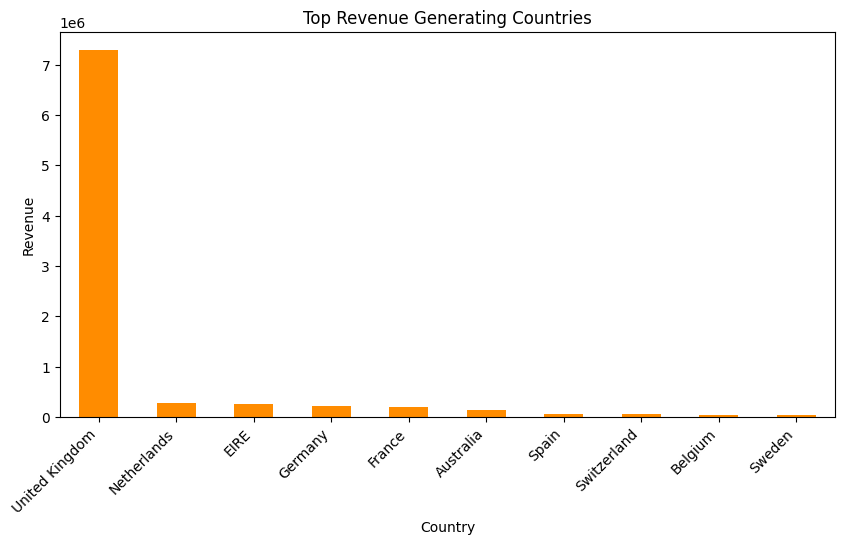

In [20]:
country_sales.plot(kind='bar', figsize=(10, 5), color='darkorange')
plt.title("Top Revenue Generating Countries")
plt.ylabel("Revenue")
plt.xlabel("Country")
plt.xticks(rotation=45, ha='right')
plt.show()

This comparison highlights where the company is most commercially successful and where expansion or diversification opportunities may exist.

## Monthly Revenue Trend
Monthly revenue helps assess seasonality and timing effects. One important context point is that December 2011 is a partial month in this dataset, so it should not be compared directly with full months.

In [21]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales

Month
2010-12     570,422.73
2011-01     568,101.31
2011-02     446,084.92
2011-03     594,081.76
2011-04     468,374.33
2011-05     677,355.15
2011-06     660,046.05
2011-07     598,962.90
2011-08     644,051.04
2011-09     950,690.20
2011-10   1,035,642.45
2011-11   1,156,205.61
2011-12     517,190.44
Freq: M, Name: Revenue, dtype: float64

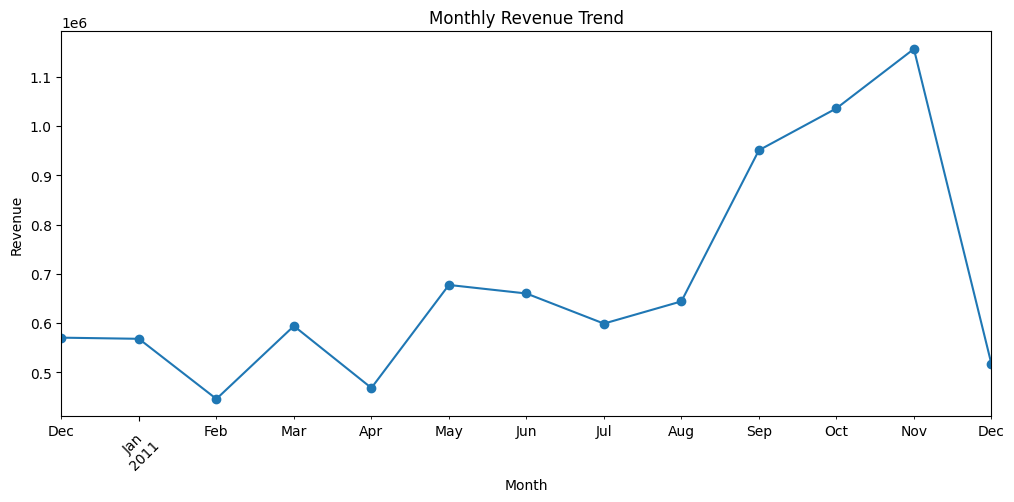

In [22]:
monthly_sales.plot(figsize=(12, 5), marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

## High Value Customers
Top customers by revenue help highlight concentration in customer spending. This can support loyalty strategy, retention programs, and targeted account management.

In [23]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646   280,206.02
18102   259,657.30
17450   194,390.79
16446   168,472.50
14911   143,711.17
12415   124,914.53
14156   117,210.08
17511    91,062.38
16029    80,850.84
12346    77,183.60
Name: Revenue, dtype: float64

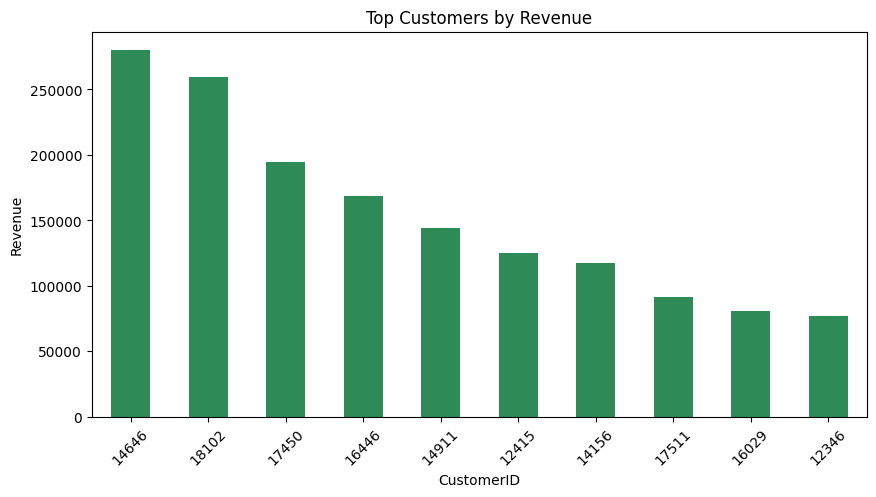

In [24]:
top_customers.plot(kind='bar', figsize=(10, 5), color='seagreen')
plt.title("Top Customers by Revenue")
plt.ylabel("Revenue")
plt.xlabel("CustomerID")
plt.xticks(rotation=45)
plt.show()

High-value customers are strong candidates for retention initiatives, premium offers, and personalized engagement.

## Key Insights
- Revenue is heavily concentrated: the top 20% of customers contribute about 74.68% of total revenue.
- Top-20%-revenue customers also drive about 59.73% of repeat orders, which supports a strong customer concentration story.
- The United Kingdom dominates country-level revenue, which suggests both market strength and concentration risk.
- A small set of products drives a disproportionately high share of unit sales, making them critical for stock planning.
- Revenue rises sharply into late 2011, showing visible seasonality, while December 2011 should be treated as a partial month.

## Business Recommendations
- Prioritize retention campaigns and loyalty efforts for the highest-value customer segment.
- Track repeat-order behavior by customer tier to identify which segments are most important for recurring revenue.
- Protect top-selling products from stockouts before peak months.
- Reduce geographic concentration risk by exploring growth in non-UK markets.
- Extend the project further with RFM segmentation, cohort retention analysis, and customer lifetime value modelling.

## Conclusion
This notebook converts raw retail transactions into a structured business analysis. The project demonstrates data cleaning, feature engineering, KPI reporting, and insight generation across products, customers, time, and geography.

For a stronger production-style workflow, the cleaned dataset can also be exported and loaded into SQL or Power BI, which is shown in the optional section below.

## Optional Export and SQL Load
The next cells are optional. They export the cleaned dataset and, if database environment variables are available, load the data into MySQL for downstream SQL analysis.

In [25]:
df.to_csv("input_data/cleaned_data.csv", index=False)
print("Cleaned data exported to input_data/cleaned_data.csv")

Cleaned data exported to input_data/cleaned_data.csv


In [26]:
from pathlib import Path
import os
import pymysql
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [27]:
load_dotenv(Path('.env'))

username = os.getenv("MYSQL_USER")
password = os.getenv("MYSQL_PASSWORD")
host = os.getenv("MYSQL_HOST", "localhost")
port = os.getenv("MYSQL_PORT", "3306")
database = os.getenv("MYSQL_DATABASE")

required_vars = {
    "MYSQL_USER": username,
    "MYSQL_PASSWORD": password,
    "MYSQL_DATABASE": database,
}
missing_vars = [key for key, value in required_vars.items() if not value]

if not missing_vars:
    engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
    rows_loaded = df.to_sql("invoices", engine, if_exists="replace", index=False)
    print(f"Loaded {rows_loaded} rows into MySQL table 'invoices'.")
else:
    print(f"Missing environment variables: {', '.join(missing_vars)}")
    print("Load them from .env or set them in the Jupyter environment before running this cell.")

Loaded 392692 rows into MySQL table 'invoices'.
